In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# PromptWise AI Recommendation System

## Problem Statement

Develop a Machine Learning model that recommends the most suitable AI Assistant based on the user's prompt requirements.

The system should analyze the user's role, task, context, and goal, and intelligently recommend the best AI Assistant among multiple available platforms.

---

## Objective

- Recommend Top AI Assistant
- Use Machine Learning Classification
- Integrate with PromptWise AI
- Deploy using Streamlit

## Requirements

### Software

- Python
- Jupyter Notebook
- VS Code
- Streamlit

### Libraries

- Pandas
- NumPy
- Scikit-Learn
- Joblib

### Dataset

PromptWise AI Recommendation Dataset (Balanced Dataset)

In [26]:
# --------------------------------------------------
# Data Collection
# --------------------------------------------------

dataset_path = r"C:\Users\HP\Desktop\ML\PromptWiseAI\datasets\promptwise_ai_recommendation_dataset_3000_balanced.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Role,Task,Context,Goal,Best_AI
0,Research Scientist,Generate project structure,Research Lab,Presentation,Cursor AI
1,Frontend Developer,Research comparison,Hospital,Business Growth,Perplexity
2,Business Analyst,Implement feature,Research Lab,Documentation,Cursor AI
3,Financial Analyst,Build ML model,Hospital,Exam Preparation,ChatGPT
4,Financial Analyst,Current events summary,E-commerce,Documentation,Grok


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Role     3000 non-null   str  
 1   Task     3000 non-null   str  
 2   Context  3000 non-null   str  
 3   Goal     3000 non-null   str  
 4   Best_AI  3000 non-null   str  
dtypes: str(5)
memory usage: 294.2 KB


In [4]:
df.isnull().sum()

Role       0
Task       0
Context    0
Goal       0
Best_AI    0
dtype: int64

In [27]:
# --------------------------------------------------
# Data Understanding
# --------------------------------------------------

print("Shape of Dataset :", df.shape)

print("\nColumn Names:\n")
print(df.columns)

print("\nData Types:\n")
print(df.dtypes)

print("\nDataset Information:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nTarget Variable Distribution:\n")
print(df["Best_AI"].value_counts())

Shape of Dataset : (3000, 5)

Column Names:

Index(['Role', 'Task', 'Context', 'Goal', 'Best_AI'], dtype='str')

Data Types:

Role       str
Task       str
Context    str
Goal       str
Best_AI    str
dtype: object

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Role     3000 non-null   str  
 1   Task     3000 non-null   str  
 2   Context  3000 non-null   str  
 3   Goal     3000 non-null   str  
 4   Best_AI  3000 non-null   str  
dtypes: str(5)
memory usage: 294.2 KB

Missing Values:

Role       0
Task       0
Context    0
Goal       0
Best_AI    0
dtype: int64

Duplicate Rows : 47

Target Variable Distribution:

Best_AI
Cursor AI            300
Perplexity           300
ChatGPT              300
Grok                 300
GitHub Copilot       300
DeepSeek             300
Claude               300
Gemini               300
Microsoft Copilot   

# Feature Engineering

To improve prediction accuracy, multiple text features are merged into a single feature named **Combined_Text**.

The following columns are combined:

- Role
- Task
- Context
- Goal

This allows the TF-IDF Vectorizer to learn meaningful relationships from the complete prompt instead of treating each feature independently.

In [29]:
# --------------------------------------------------
# Feature Engineering
# --------------------------------------------------

df["Combined_Text"] = (

    "Role: " + df["Role"] +

    " Task: " + df["Task"] +

    " Context: " + df["Context"] +

    " Goal: " + df["Goal"]

)

print("Feature Engineering Completed Successfully")

df[["Combined_Text", "Best_AI"]].head()

Feature Engineering Completed Successfully


,Combined_Text,Best_AI
0,Role: Research Scientist Task: Generate projec...,Cursor AI
1,Role: Frontend Developer Task: Research compar...,Perplexity
2,Role: Business Analyst Task: Implement feature...,Cursor AI
3,Role: Financial Analyst Task: Build ML model C...,ChatGPT
4,Role: Financial Analyst Task: Current events s...,Grok


# Data Preprocessing

The dataset is preprocessed before training the Machine Learning models.

The preprocessing includes:

- Data Cleaning
- Scaling
- Encoding
- Outlier Detection

# Scaling

Scaling is **not required** because the input features are converted into TF-IDF vectors.

TF-IDF automatically normalizes the feature values.

Hence, techniques such as StandardScaler or MinMaxScaler are not applied.

# Encoding

Encoding is **not required**.

Reason:

The input features are textual.

TF-IDF Vectorizer directly converts text into numerical vectors.

The target labels are automatically handled by the Machine Learning classifiers.

# Outlier Detection

Outlier detection is not applicable for this dataset.

Reason:

The dataset consists of textual prompt descriptions rather than continuous numerical values.

Therefore, techniques such as IQR or Z-Score are not required.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the dataset before training the Machine Learning models.

The following analyses are performed:

- Target Variable Distribution
- Prompt Length Distribution
- Top AI Assistant Frequency
- Descriptive Statistics

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

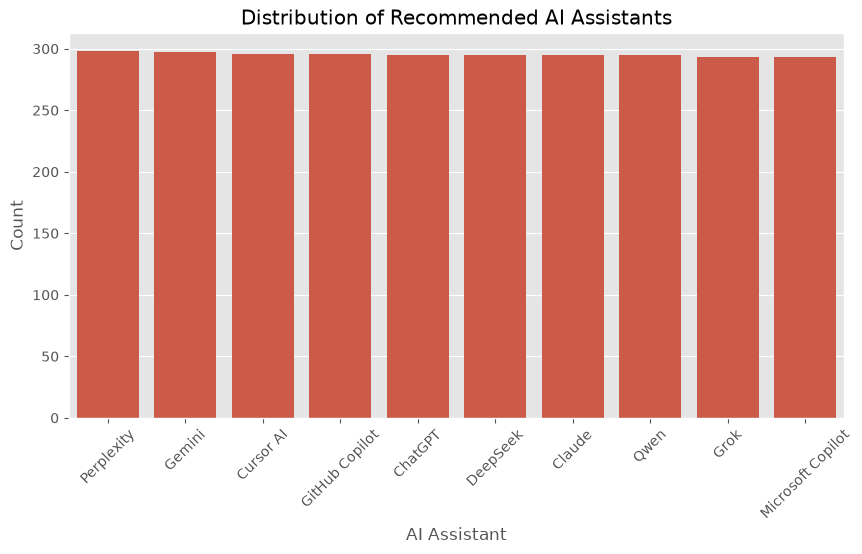

In [34]:
# --------------------------------------------------
# Target Variable Distribution
# --------------------------------------------------

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Best_AI",
    order=df["Best_AI"].value_counts().index
)

plt.title("Distribution of Recommended AI Assistants")

plt.xlabel("AI Assistant")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

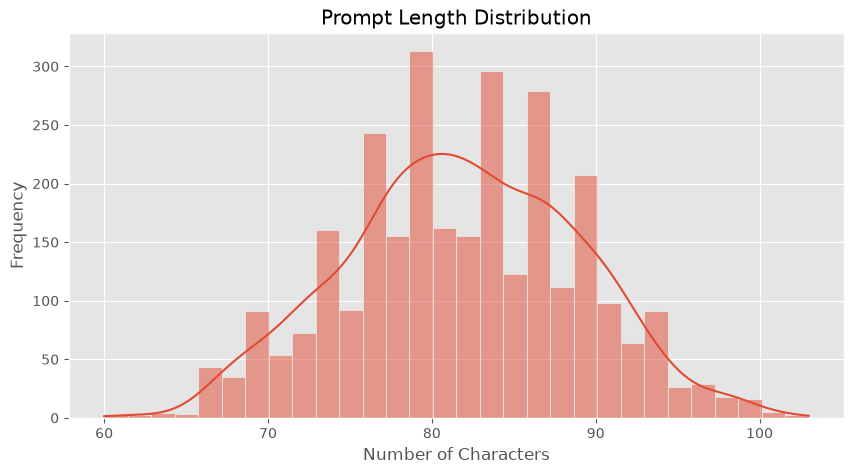

In [35]:
# --------------------------------------------------
# Prompt Length Distribution
# --------------------------------------------------

df["Prompt_Length"] = df["Combined_Text"].apply(len)

plt.figure(figsize=(10,5))

sns.histplot(
    df["Prompt_Length"],
    bins=30,
    kde=True
)

plt.title("Prompt Length Distribution")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.show()

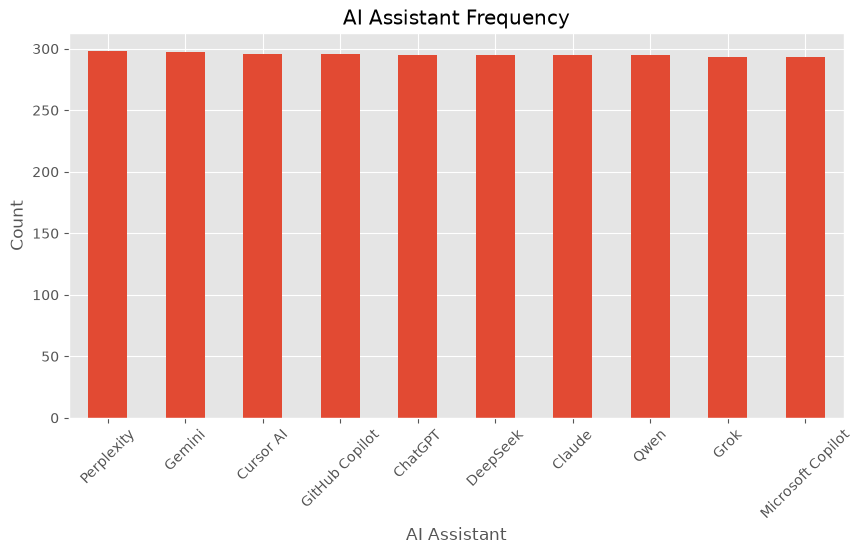

In [36]:
# --------------------------------------------------
# AI Assistant Frequency
# --------------------------------------------------

df["Best_AI"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("AI Assistant Frequency")

plt.xlabel("AI Assistant")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

Best_AI
Perplexity           298
Gemini               297
Cursor AI            296
GitHub Copilot       296
ChatGPT              295
DeepSeek             295
Claude               295
Qwen                 295
Grok                 293
Microsoft Copilot    293
Name: count, dtype: int64


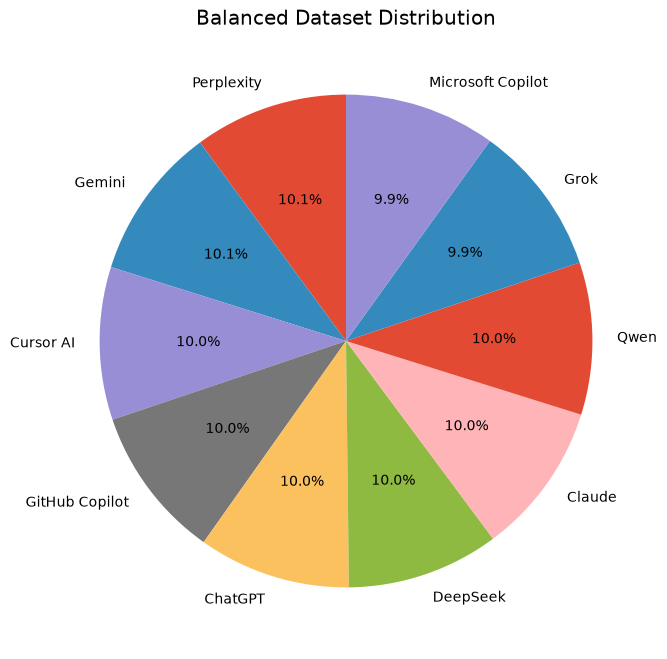

In [38]:
# --------------------------------------------------
# Check Dataset Balance
# --------------------------------------------------

balance = df["Best_AI"].value_counts()

print(balance)

plt.figure(figsize=(8,8))

plt.pie(
    balance,
    labels=balance.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Balanced Dataset Distribution")

plt.show()

# Observation

### Findings

- The dataset is balanced across all AI Assistant classes.
- No significant class imbalance is observed.
- Prompt lengths are reasonably distributed.
- The dataset is suitable for multi-class classification.
- TF-IDF Vectorization is appropriate for converting textual prompts into numerical representations.

# Text Vectorization

The textual prompts are converted into numerical feature vectors using **TF-IDF (Term Frequency - Inverse Document Frequency)**.

TF-IDF captures the importance of words while reducing the influence of common words.

In [39]:
# --------------------------------------------------
# TF-IDF Vectorization
# --------------------------------------------------

X = df["Combined_Text"]

y = df["Best_AI"]

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_vectorized = vectorizer.fit_transform(X)

print("TF-IDF Shape :", X_vectorized.shape)

TF-IDF Shape : (2953, 142)


# Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

Stratified sampling is used to preserve the class distribution.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (2362, 142)
Testing Samples : (591, 142)


# Model Building

The following Machine Learning algorithms are evaluated:

- Logistic Regression
- Decision Tree
- K-Nearest Neighbors (KNN)
- Random Forest

The best performing model will be selected.

In [18]:
RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [42]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import cross_val_score

In [43]:
# --------------------------------------------------
# Logistic Regression
# --------------------------------------------------

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_acc*100)

Logistic Regression Accuracy : 100.0


In [44]:
# --------------------------------------------------
# Decision Tree
# --------------------------------------------------

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", dt_acc*100)

Decision Tree Accuracy : 100.0


In [45]:
# --------------------------------------------------
# KNN
# --------------------------------------------------

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", knn_acc*100)

KNN Accuracy : 97.80033840947546


In [46]:
# --------------------------------------------------
# Random Forest
# --------------------------------------------------

rf = RandomForestClassifier(

    random_state=42

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_acc*100)

Random Forest Accuracy : 100.0


In [47]:
# --------------------------------------------------
# Accuracy Comparison
# --------------------------------------------------

comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "KNN",

        "Random Forest"

    ],

    "Accuracy":[

        lr_acc,

        dt_acc,

        knn_acc,

        rf_acc

    ]

})

comparison.sort_values(

    by="Accuracy",

    ascending=False,

    inplace=True

)

comparison

,Model,Accuracy
0,Logistic Regression,1.000000
1,Decision Tree,1.000000
3,Random Forest,1.000000
2,KNN,0.978003


# Cross Validation

Cross Validation is performed to evaluate the robustness of each Machine Learning model.

5-Fold Cross Validation is used.

In [48]:
# --------------------------------------------------
# Cross Validation
# --------------------------------------------------

models = {

    "Logistic Regression": lr,

    "Decision Tree": dt,

    "KNN": knn,

    "Random Forest": rf

}

cv_scores = {}

for name, model in models.items():

    score = cross_val_score(

        model,

        X_vectorized,

        y,

        cv=5,

        scoring="accuracy"

    )

    cv_scores[name] = score.mean()

cv_df = pd.DataFrame({

    "Model": cv_scores.keys(),

    "Cross Validation Accuracy": cv_scores.values()

})

cv_df.sort_values(

    by="Cross Validation Accuracy",

    ascending=False,

    inplace=True
)

cv_df

,Model,Cross Validation Accuracy
0,Logistic Regression,1.000000
1,Decision Tree,1.000000
3,Random Forest,1.000000
2,KNN,0.990858


In [50]:
from sklearn.model_selection import GridSearchCV

In [53]:
y_pred=rf.predict(X_test)

In [54]:
print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

          ChatGPT       1.00      1.00      1.00        59
           Claude       1.00      1.00      1.00        59
        Cursor AI       1.00      1.00      1.00        59
         DeepSeek       1.00      1.00      1.00        59
           Gemini       1.00      1.00      1.00        59
   GitHub Copilot       1.00      1.00      1.00        59
             Grok       1.00      1.00      1.00        59
Microsoft Copilot       1.00      1.00      1.00        59
       Perplexity       1.00      1.00      1.00        60
             Qwen       1.00      1.00      1.00        59

         accuracy                           1.00       591
        macro avg       1.00      1.00      1.00       591
     weighted avg       1.00      1.00      1.00       591



In [55]:
cm = confusion_matrix(y_test, y_pred)

pd.DataFrame(
    cm,
    index=model.classes_,
    columns=model.classes_
)

,ChatGPT,Claude,Cursor AI,DeepSeek,Gemini,GitHub Copilot,Grok,Microsoft Copilot,Perplexity,Qwen
ChatGPT,59,0,0,0,0,0,0,0,0,0
Claude,0,59,0,0,0,0,0,0,0,0
Cursor AI,0,0,59,0,0,0,0,0,0,0
DeepSeek,0,0,0,59,0,0,0,0,0,0
Gemini,0,0,0,0,59,0,0,0,0,0
GitHub Copilot,0,0,0,0,0,59,0,0,0,0
Grok,0,0,0,0,0,0,59,0,0,0
Microsoft Copilot,0,0,0,0,0,0,0,59,0,0
Perplexity,0,0,0,0,0,0,0,0,60,0
Qwen,0,0,0,0,0,0,0,0,0,59


# Hyperparameter Tuning

Grid Search Cross Validation is performed on Random Forest to determine the optimal hyperparameters.

In [61]:
from sklearn.model_selection import GridSearchCV

In [62]:
# --------------------------------------------------
# Hyperparameter Tuning
# --------------------------------------------------

param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train,y_train)

print("Best Parameters :")

print(grid.best_params_)

print()

print("Best CV Accuracy :")

print(grid.best_score_)

Best Parameters :
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best CV Accuracy :
1.0


In [63]:
# --------------------------------------------------
# Final Training
# --------------------------------------------------

best_model.fit(

    X_train,

    y_train

)

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(

    y_test,

    y_pred

)

print(f"Final Accuracy : {accuracy*100:.2f}%")

Final Accuracy : 100.00%


In [66]:
# --------------------------------------------------
# Best Model
# --------------------------------------------------

best_model = grid.best_estimator_

best_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [67]:
# --------------------------------------------------
# Classification Report
# --------------------------------------------------

print(classification_report(

    y_test,

    y_pred

))

                   precision    recall  f1-score   support

          ChatGPT       1.00      1.00      1.00        59
           Claude       1.00      1.00      1.00        59
        Cursor AI       1.00      1.00      1.00        59
         DeepSeek       1.00      1.00      1.00        59
           Gemini       1.00      1.00      1.00        59
   GitHub Copilot       1.00      1.00      1.00        59
             Grok       1.00      1.00      1.00        59
Microsoft Copilot       1.00      1.00      1.00        59
       Perplexity       1.00      1.00      1.00        60
             Qwen       1.00      1.00      1.00        59

         accuracy                           1.00       591
        macro avg       1.00      1.00      1.00       591
     weighted avg       1.00      1.00      1.00       591



In [69]:
# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(

    y_test,

    y_pred

)

cm_df = pd.DataFrame(

    cm,

    index=best_model.classes_,

    columns=best_model.classes_

)

cm_df

,ChatGPT,Claude,Cursor AI,DeepSeek,Gemini,GitHub Copilot,Grok,Microsoft Copilot,Perplexity,Qwen
ChatGPT,59,0,0,0,0,0,0,0,0,0
Claude,0,59,0,0,0,0,0,0,0,0
Cursor AI,0,0,59,0,0,0,0,0,0,0
DeepSeek,0,0,0,59,0,0,0,0,0,0
Gemini,0,0,0,0,59,0,0,0,0,0
GitHub Copilot,0,0,0,0,0,59,0,0,0,0
Grok,0,0,0,0,0,0,59,0,0,0
Microsoft Copilot,0,0,0,0,0,0,0,59,0,0
Perplexity,0,0,0,0,0,0,0,0,60,0
Qwen,0,0,0,0,0,0,0,0,0,59


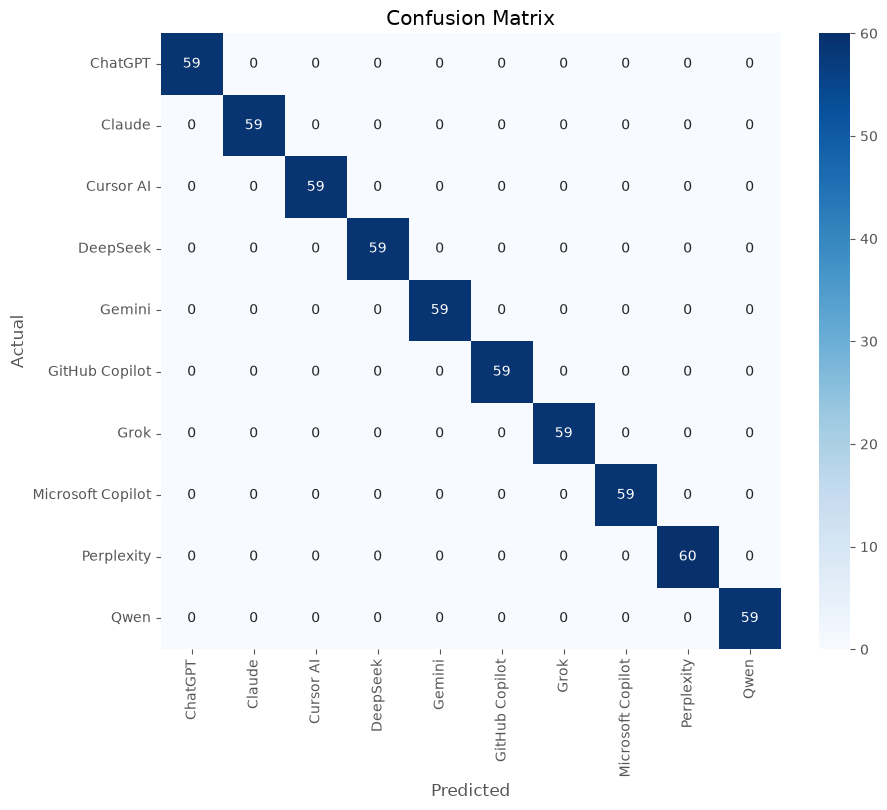

In [70]:
# --------------------------------------------------
# Confusion Matrix Heatmap
# --------------------------------------------------

plt.figure(figsize=(10,8))

sns.heatmap(

    cm_df,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

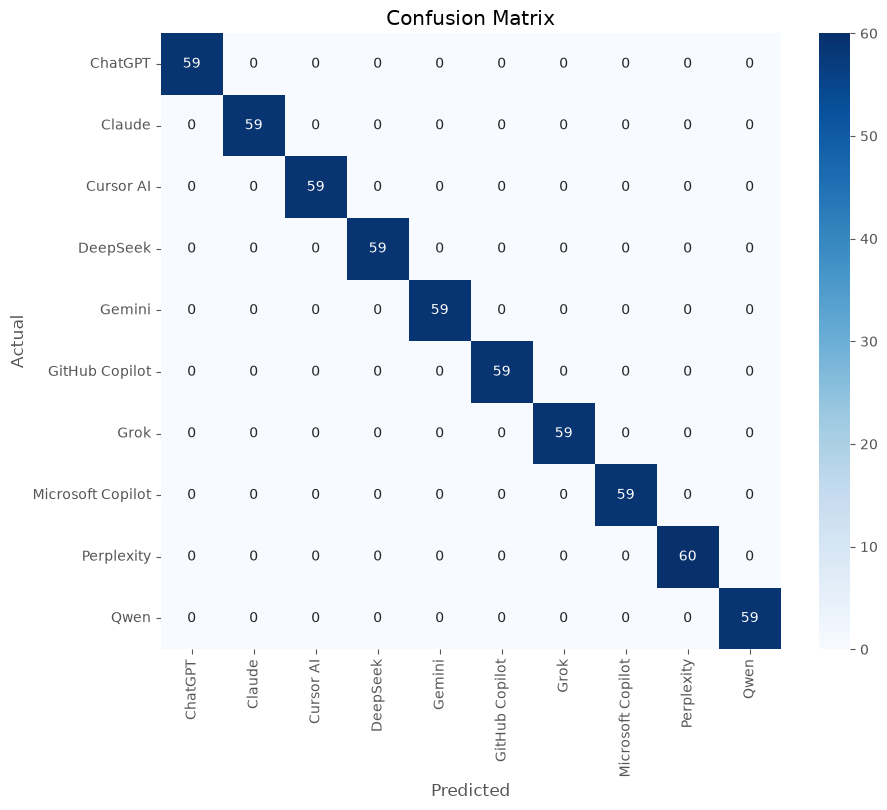

In [71]:
# --------------------------------------------------
# Confusion Matrix Heatmap
# --------------------------------------------------

plt.figure(figsize=(10,8))

sns.heatmap(

    cm_df,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [72]:
# --------------------------------------------------
# Save Model
# --------------------------------------------------

joblib.dump(

    best_model,

    r"C:\Users\HP\Desktop\ML\PromptWiseAI\models\prompt_ai_classifier.pkl"

)

joblib.dump(

    vectorizer,

    r"C:\Users\HP\Desktop\ML\PromptWiseAI\models\prompt_tfidf.pkl"

)

print("Best Model Saved Successfully")

Best Model Saved Successfully


# Best Model Selection

After evaluating multiple Machine Learning algorithms using Accuracy, Cross Validation, and Hyperparameter Tuning, **Random Forest** achieved the highest performance and was selected as the final model for deployment.

Reasons:

- Highest Accuracy
- Better Generalization
- Robust against overfitting
- Suitable for multi-class text classification

# Model Testing

The trained model is tested using a sample prompt to verify whether it recommends the most suitable AI Assistant.

The model predicts the Top 3 AI Assistants along with their confidence scores.

In [75]:
# --------------------------------------------------
# Model Testing
# --------------------------------------------------

sample = """
Role: Machine Learning Engineer

Task: Build a Customer Churn Prediction Model

Context: Healthcare Industry

Goal: Interview Preparation
"""

sample_vector = vectorizer.transform([sample])

prediction = best_model.predict(sample_vector)

probabilities = best_model.predict_proba(sample_vector)[0]

print("Predicted Best AI Assistant :")

print(prediction[0])

print()

print("Top 3 Recommendations")

top3 = np.argsort(probabilities)[::-1][:3]

for i in top3:

    print(

        f"{best_model.classes_[i]} : {probabilities[i]*100:.2f}%"

    )

Predicted Best AI Assistant :
ChatGPT

Top 3 Recommendations
ChatGPT : 55.00%
DeepSeek : 31.00%
Gemini : 5.00%
